In [1]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM
from transformers  import AutoTokenizer
import pandas as pd 
import pyarrow.dataset as ds
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from Early_stopping_class import EarlyStopping
import random


In [2]:
device = torch.device("cuda:1")


#### Load the base model 

In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
local_model_path = "models/Qwen/Qwen3-1.7B" # Path to the downloaded model directory
device = torch.device("cuda:1")


# Load model in 4-bit to save memory (important for keyboard research)
Qwen_model = AutoModelForCausalLM.from_pretrained(
    local_model_path, 
    #device_map={ " " : 1},  # Automatically distribute layers across available devices
    torch_dtype=torch.float16,
    #load_in_4bit=True,
    local_files_only=True,
    trust_remote_code=True,
).to(device)

tokenizer = AutoTokenizer.from_pretrained(
    local_model_path, 
    local_files_only=True,
    trust_remote_code=True)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


#### Define the router class

In [4]:
class Router(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
    
    def forward(self,x):
        return self.mlp(x)
    

In [5]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [6]:
def get_embedding(text, model, tokenizer, device):
    # Change padding to False for extraction
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True # <--- FIXED: No padding means -1 is always the last REAL token
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # We take the last layer's hidden state for the last token
    last_hidden = outputs.hidden_states[-1] 
    embedding = last_hidden[:, -1, :] # Now this is definitely the last word!
    
    return embedding.float()

In [7]:
emb = get_embedding("Bonjour bro how are you ?", Qwen_model, tokenizer, device)

print(emb.shape)
print(emb)


torch.Size([1, 2048])
tensor([[ 0.4875, -1.8262, -0.7378,  ..., -0.6230, -0.7061, -0.4548]],
       device='cuda:1')


#### Prepare the data 

In [8]:
LABEL_BASE = 0      # English only
LABEL_FR   = 1      # EN-FR adapter
LABEL_ZH   = 2      # ZH-EN adapter

# EN-FR dataset 
df = pd.read_csv('French_eng.csv')
df_fr= df['data_generation_result']

# EN-ZH dataset
dataset = ds.dataset("./Chinese_eng" , format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df_zh = df['transcription']

# EN dataset 
lines = []
with open("English_text.txt", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 20000:  
            break
        stripped = line.strip()
        if stripped:  # Skip empty lines
            lines.append(stripped)
df_en = pd.Series(lines)


In [9]:
len(df_en) , len(df_fr) , len(df_zh)

(20000, 8070, 15000)

In [10]:
# Clean and standardize the datasets
df_fr = df_fr.dropna().astype(str)
df_zh = df_zh.dropna().astype(str)
df_en = df_en.dropna().astype(str)

 # Create prefix generator word level 
def word_prefixes(text, max_prefixes=10):
    words = text.split()
    prefixes = []
    
    for i in range(1, min(len(words) + 1, max_prefixes + 1)):
        prefixes.append(" ".join(words[:i]))
    
    return prefixes

# Create prefix generator character level
def char_prefixes(text, max_chars=20):
    prefixes = []
    text = text.strip()
    
    for i in range(1, min(len(text), max_chars)):
        prefixes.append(text[:i])
    
    return prefixes

# Combine both of them 
def generate_samples(text):
    samples = []
    
    # word-level
    samples.extend(word_prefixes(text))
    
    # char-level (sample some, not all)
    char_samples = char_prefixes(text)
    if len(char_samples) > 5:
        char_samples = random.sample(char_samples, 5)
    
    samples.extend(char_samples)
    
    return samples

#### Build training and testing datasets 

In [11]:
texts = []
labels = []

for text in df_en:
    samples = generate_samples(text)
    for s in samples:
        texts.append(s)
        labels.append(LABEL_BASE)

for text in df_fr:
    samples = generate_samples(text)
    for s in samples:
        texts.append(s)
        labels.append(LABEL_FR)

for text in df_zh:
    samples = generate_samples(text)
    for s in samples:
        texts.append(s)
        labels.append(LABEL_ZH)

In [12]:
len(texts) , len(labels) , texts[:5] , labels[:5]

(637370,
 637370,
 ['Soon',
  'Soon we',
  'Soon we dropped',
  'Soon we dropped into',
  'Soon we dropped into a'],
 [0, 0, 0, 0, 0])

In [13]:
# Shuffle the dataset 
combined = list(zip(texts, labels))
random.shuffle(combined)

texts, labels = zip(*combined)
texts = list(texts)
labels = list(labels)

In [16]:
from collections import Counter
print(Counter(labels))
X = []  
y = []

Counter({0: 120890, 2: 120890, 1: 120890})


In [15]:
## Try this if the model is biased to balance the dataset 

min_size = min(Counter(labels).values())

new_X, new_y = [], []

counts = {0:0, 1:0, 2:0}

for xi, yi in zip(texts, labels):
    if counts[yi] < min_size:
        new_X.append(xi)
        new_y.append(yi)
        counts[yi] += 1

texts, labels = new_X, new_y

In [17]:
# --- STEP A: PREPARE THE MODEL ---
dataset = TextDataset(texts, labels)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False
)

#Qwen_model.disable_adapter() # CRITICAL: Ensure you aren't using an expert to train the router
Qwen_model.eval()

# --- STEP B: RUN THE EXTRACTION ---
all_embeddings = []
for batch_texts, batch_labels in tqdm(loader, desc="Extracting Clean Features"):
    emb = get_embedding(batch_texts, Qwen_model, tokenizer, device)
    all_embeddings.append(emb.cpu().float())

X = torch.cat(all_embeddings).float() 
y = torch.tensor(labels)

Extracting Clean Features: 100%|██████████| 5667/5667 [05:59<00:00, 15.77it/s]


In [18]:
X.shape , y.shape

(torch.Size([362670, 2048]), torch.Size([362670]))

In [19]:
# 1. Split into Train and Validation (Crucial for your thesis results!)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Create Datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
router = Router(hidden_size=X.shape[1]).to(device)

optimizer = torch.optim.Adam(router.parameters(), lr=5e-5)
loss_fn = nn.CrossEntropyLoss()
early_stopping = EarlyStopping(patience=5, save_path="./router_best1")

num_epochs = 30
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):

    # ================= TRAIN =================
    router.train()
    train_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for xb, yb in train_bar:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = router(xb)
        loss = loss_fn(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

        # update tqdm
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(correct/total):.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    print(f"\nEpoch {epoch+1} Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    # ================= VALIDATION =================
    router.eval()
    val_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = router(xb)
            loss = loss_fn(logits, yb)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)


    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1} Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    early_stopping(val_loss, router)
    
    if early_stopping.early_stop:
        print("Early stopping")
        break

Epoch 1 [Train]:   0%|          | 0/4534 [00:00<?, ?it/s]

Epoch 1 [Train]: 100%|██████████| 4534/4534 [00:19<00:00, 228.77it/s, loss=0.2935, acc=0.8968]



Epoch 1 Train Loss: 0.2676 | Train Acc: 0.8968

Epoch 1 Val Loss: 0.2008 | Val Acc: 0.9165
✅ Val Loss Improved (inf -> 0.2008). Saving model...


Epoch 2 [Train]: 100%|██████████| 4534/4534 [00:19<00:00, 234.34it/s, loss=0.1404, acc=0.9185]



Epoch 2 Train Loss: 0.1940 | Train Acc: 0.9185

Epoch 2 Val Loss: 0.1877 | Val Acc: 0.9206
✅ Val Loss Improved (0.2008 -> 0.1877). Saving model...


...


Epoch 26 Train Loss: 0.1552 | Train Acc: 0.9334

Epoch 26 Val Loss: 0.1685 | Val Acc: 0.9279
⚠️ No improvement. Patience: 3/5


Epoch 27 [Train]: 100%|██████████| 4534/4534 [00:18<00:00, 240.45it/s, loss=0.2498, acc=0.9341]



Epoch 27 Train Loss: 0.1545 | Train Acc: 0.9341

Epoch 27 Val Loss: 0.1701 | Val Acc: 0.9269
⚠️ No improvement. Patience: 4/5


Epoch 28 [Train]: 100%|██████████| 4534/4534 [00:20<00:00, 220.53it/s, loss=0.1442, acc=0.9342]



Epoch 28 Train Loss: 0.1536 | Train Acc: 0.9342

Epoch 28 Val Loss: 0.1687 | Val Acc: 0.9274
⚠️ No improvement. Patience: 5/5
Early stopping


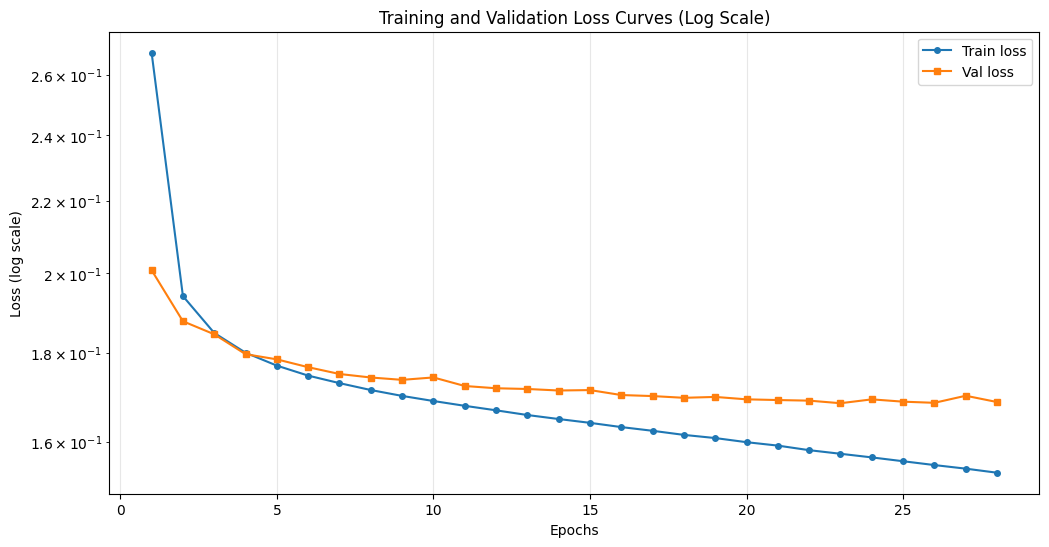

In [28]:
import matplotlib.pyplot as plt
epochs_count = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_count, train_losses, label='Train loss', marker='o', markersize=4)
plt.plot(epochs_count, val_losses, label='Val loss', marker='s', markersize=4)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.title('Training and Validation Loss Curves (Log Scale)')
plt.ylabel('Loss (log scale)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [29]:
torch.manual_seed(42)
loaded_router = Router(hidden_size=2048).to(device)

loaded_router.load_state_dict(torch.load(f="./router_best.pth"))

loaded_router.to(device)

Router(
  (mlp): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [34]:
import torch
import torch.nn.functional as F

# 1. Define the Prediction Function
def predict_language(text, model, tokenizer, router, device, mapping):
    """
    Takes a string, extracts the base-model embedding, 
    and uses the MLP router to predict the language.
    """
    # Set models to evaluation mode
    model.eval()
    router.eval()
    
    # 2. Tokenize (No padding needed for single-sentence inference)
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        truncation=True, 
        padding=True
    ).to(device)

    # 3. Get Hidden States from Base Model
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        
        # Access the last layer: outputs.hidden_states[-1] 
        # Shape: [batch_size, sequence_length, hidden_size]
        last_layer = outputs.hidden_states[-1]
        
        # CRITICAL: Select only the LAST token's hidden state
        # This collapses the [1, seq_len, 1536] tensor to [1, 1536]
        # This prevents the '38 elements cannot be converted to scalar' error
        embedding = last_layer[:, -1, :].float()  # Ensure it's float for the router 

        # 4. Router Forward Pass
        logits = router(embedding)
        
        # 5. Convert Logits to Probabilities
        probs = F.softmax(logits, dim=1)
    
    # Get the index of the highest probability
    # .item() now works because we have exactly 1 row (batch size 1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_idx].item()
    
    return mapping[pred_idx], confidence, probs[0].cpu().numpy()

# --- 2. Setup the Test Environment ---

# Define your mapping based on your training labels
# LABEL_BASE = 0, LABEL_FR = 1, LABEL_ZH = 2
lang_mapping = {0: "English", 1: "French", 2: "Chinese"}

# List of test cases (Pure and Mixed)
test_sentences = [
    "I'm currently working on my master's thesis in NLP", # English
    "Je voudrais un croissant et un café, s'il vous plaît", # French
    "你好，我正在学习人工智能技术",                         # Chinese
    "Let's meet at the café for a quick rendezvous",      # Mixed (EN/FR)
    "I really like this 你好 style of greeting" ,          # Mixed (EN/ZH)
    "Je voudrais go to the school but je sais pas comment y aller" ,# Mixed (EN/FR)
    "Je crois que c'est une bonne idée" ,
    "Je veux un croissant et du lait, s'il vous plait" ,# French
    "I had coffe this",
    "Bonjour je m'appele",
    "I think you need",
    "Nihao, wo shi xuesheng" # Mixed (EN/ZH)
]

# --- 3. Execute Tests ---
print(f"{'Text':<50} | {'Prediction':<10} | {'Confidence'}")
print("-" * 80)

for text in test_sentences:
    lang, conf, raw_probs = predict_language(
        text, Qwen_model, tokenizer, loaded_router, device, lang_mapping
    )
    print(f"{text[:50]:<50} | {lang:<10} | {conf*100:.2f}%")

Text                                               | Prediction | Confidence
--------------------------------------------------------------------------------
I'm currently working on my master's thesis in NLP | English    | 77.85%
Je voudrais un croissant et un café, s'il vous pla | French     | 99.78%
你好，我正在学习人工智能技术                                     | Chinese    | 100.00%
Let's meet at the café for a quick rendezvous      | Chinese    | 98.57%
I really like this 你好 style of greeting            | Chinese    | 99.97%
Je voudrais go to the school but je sais pas comme | French     | 99.95%
Je crois que c'est une bonne idée                  | French     | 90.44%
Je veux un croissant et du lait, s'il vous plait   | French     | 99.97%
I had coffe this                                   | Chinese    | 93.27%
Bonjour je m'appele                                | French     | 99.96%
I think you need                                   | Chinese    | 75.08%
Nihao, wo shi xuesheng                

In [17]:
import torch.nn.functional as F

def route_embedding(emb):
    emb = emb.float().to(device)  # Convert to float32 to match router
    with torch.no_grad():
        probs = F.softmax(router(emb), dim=-1)
    return probs.squeeze().cpu().numpy()

In [18]:
print(route_embedding(get_embedding("Bonjour bro", Qwen_model, tokenizer, device)))
print(route_embedding(get_embedding("你好 bro", Qwen_model, tokenizer, device)))
print(route_embedding(get_embedding("Hello bro", Qwen_model, tokenizer, device)))

[9.9998498e-01 1.5059894e-05 1.3745259e-13]
[9.9996519e-01 3.3278411e-05 1.5625676e-06]
[9.9999690e-01 3.0488739e-06 1.2781957e-08]


In [22]:
def route_prediction(text, model, tokenizer, router, device):
    emb = get_embedding(text, model, tokenizer, device).float()
    router.eval()
    with torch.no_grad():
        logits = router(emb)
        # Apply softmax to get clear 0.0 - 1.0 probabilities
        probs = torch.softmax(logits, dim=1)
    
    # Mapping indices back to names
    # Ensure these match the order you used when filling the labels list!
    mapping = {0: "English", 1: "French", 2: "Chinese"}
    
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_idx].item()
    
    return f"Language: {mapping[pred_idx]} ({confidence*100:.2f}%)"

# Test again
print(route_prediction("Hello my friend how are you ? ", Qwen_model, tokenizer, router, device))

Language: Chinese (95.13%)
